In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Regression linear in parameters
In this notebook, we will explore how to use linear regression for an example in which the data itself is nonlinear but linear in parameters.

Note in fact that the $y$ is generated by taking a power of $X$. 

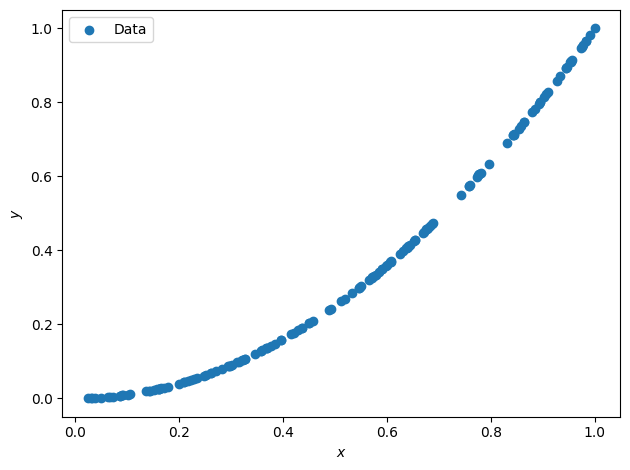

In [ ]:
X = np.random.rand(150,1)
y = X**2

plt.scatter(X,y,label="Data")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

With some little modification, we can adapt linear regression to be able to fit this!

Write a function to generate polynomial features up to a certain degree (optional: also provide the option to include a bias column).

Then, the coefficients size (number of elements) will depend on the degree. Modify the evaluation function to use the `generate_polynomial_features` function as well.

In [3]:
def generate_polynomial_features(x, degree=4):
    cols = [ x**i for i in range(0,degree+1)]
    return np.column_stack(cols)

def find_coefficients(X,y):
    theta = np.linalg.solve(X.T@X, X.T@y)
    return theta

def eval_regression(X, coeffs, degree=4):
    X_poly = generate_polynomial_features(X, degree)
    return X_poly @ coeffs

Now, the same `find_coefficients` function works nevertheless, and can find non-linear (but linear in parameters) fits.

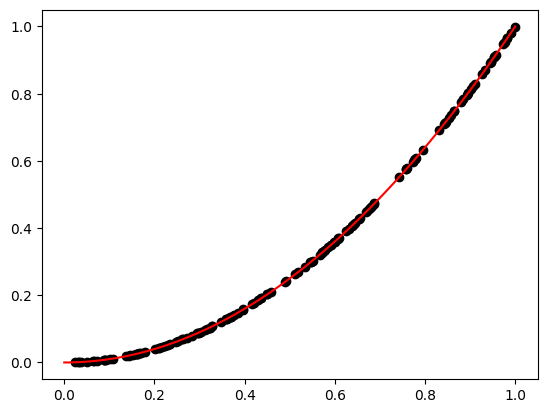

In [4]:
X_poly = generate_polynomial_features(X, degree=10)
coeffs = find_coefficients(X_poly, y)

X_plot = np.linspace(0,1,100)
y_pred = eval_regression(X_plot, coeffs, degree=10)

plt.plot(X_plot, y_pred, c='r')
plt.scatter(X, y, c='k')
plt.show()

# Example 2
What if instead, we had noise in the data?

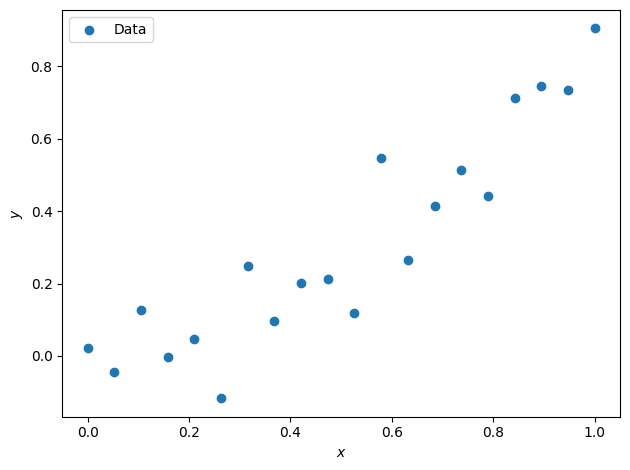

In [5]:
X = np.linspace(0, 1, 20).reshape(20,1)
y = X**2 + 0.1*np.random.randn(20,1)

plt.scatter(X,y,label="Data")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

Now, fitting a polynomial of degree 2 gives us a reasonable output.

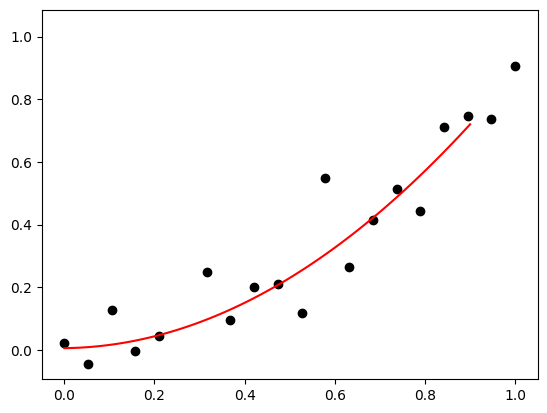

In [6]:
X_poly = generate_polynomial_features(X, degree=2)
coeffs = find_coefficients(X_poly, y)


X_plot = np.linspace(0,0.9,100)
y_pred = eval_regression(X_plot, coeffs, degree=2)

plt.plot(X_plot, y_pred, c='r')
plt.scatter(X, y, c='k')
plt.ylim(bottom=y.min()*0.8, top=y.max()*1.2)
plt.show()

However, increasing the degree of the polynomial gives a "more interpolant" fit, which makes no sense considering that we know how the data was generated. If we did *not* know, we would however look at the error and be brought to consider that this fit is more "true to the data"...

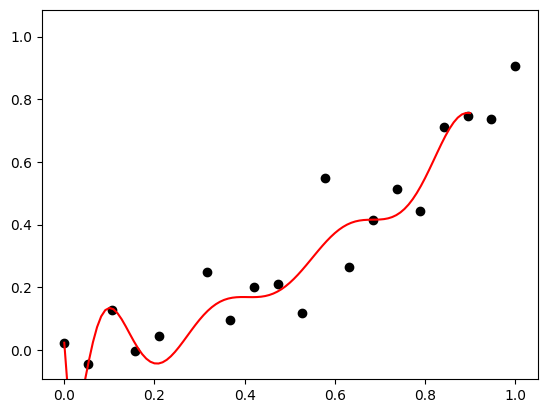

In [7]:
X_poly = generate_polynomial_features(X, degree=20)
coeffs = find_coefficients(X_poly, y)


X_plot = np.linspace(0,0.9,100)
y_pred = eval_regression(X_plot, coeffs, degree=20)

plt.plot(X_plot, y_pred, c='r')
plt.scatter(X, y, c='k')
plt.ylim(bottom=y.min()*0.8, top=y.max()*1.2)
plt.show()